In [1]:
'''
The idea is to construct your first Neural Network using tensorflow.keras and some tools from scikit-learn if
you want. The exercise will be to generate a simple classifier that take the 2 coordinates of a point (x,y) and
return the type of the point (blue or red). We provide you the data points in the GoogleDrive under the name
Data_points_nonlin.txt. The first 2 columns represent the x and y coordinates of the points and the third
column represents the type of the data point (o for blue and 1 for red).
'''

import tensorflow.keras  as keras
from tensorflow.keras.models import Sequential
from sklearn.metrics import accuracy_score
from tensorflow.keras.layers import Dense,Activation,Dropout
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

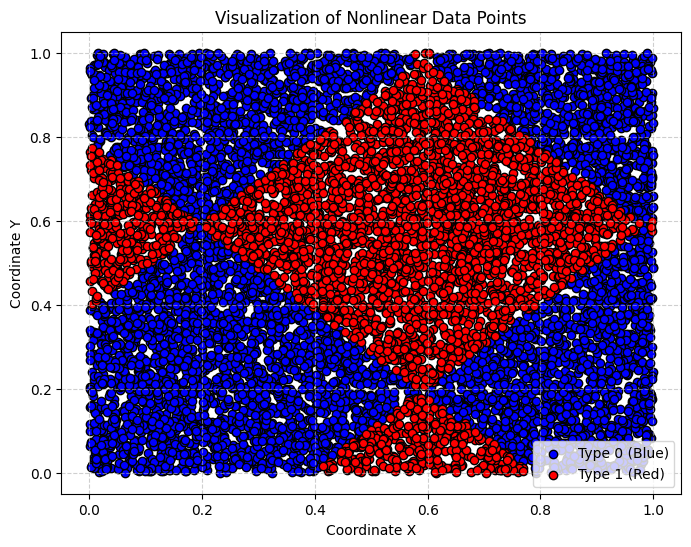

In [2]:
'''
1.2 Visualization and preparation of the data
'''
data = np.loadtxt('/Users/alfonsozapata/Downloads/Data_points_nonlin.txt')

x,y,labels = data[:, 0],data[:, 1], data[:, 2]

# Filter points based on their type
x_blue,y_blue = x[labels == 0], y[labels == 0]

x_red,y_red = x[labels == 1], y[labels == 1]


plt.figure(figsize=(8, 6))
plt.scatter(x_blue, y_blue, color='blue', label='Type 0 (Blue)', edgecolors='k')
plt.scatter(x_red, y_red, color='red', label='Type 1 (Red)', edgecolors='k')
plt.title('Visualization of Nonlinear Data Points')
plt.xlabel('Coordinate X')
plt.ylabel('Coordinate Y')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


In [3]:
# 2) sub-select 80% of the data points for the training set and 20% for the validation set
# X contains the coordinates (columns 0 and 1)
# y contains the target classes (column 2)
X = data[:, :2]
y = data[:, 2]
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Validation set size: {X_val.shape[0]} samples")

Training set size: 8000 samples
Validation set size: 2000 samples


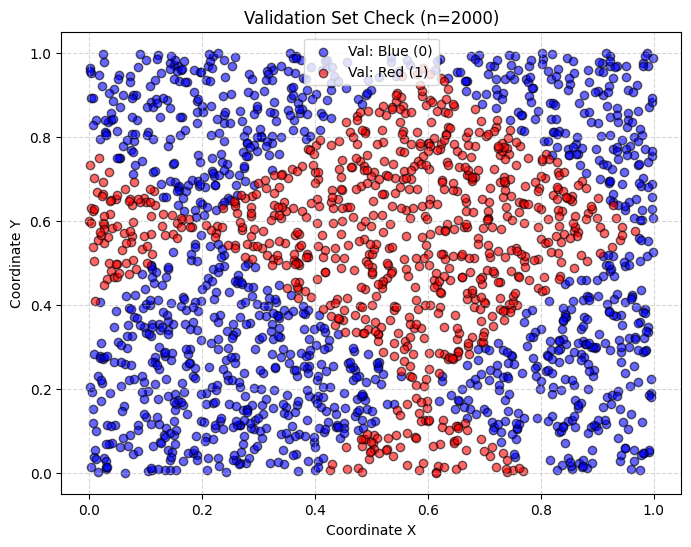

In [4]:
'''
Do the same plot as question 1) but only for the validation set in order to control that this set is representative of the full (x,y) space. Feel free to use from sklearn.model_selection import train_test_split , but it is not necessary.
# X_val[:, 0] is the x-coordinate, X_val[:, 1] is the y-coordinate
# y_val is the color label (0 or 1)
'''
plt.figure(figsize=(8, 6))

# We use y_val (the 20% labels) to filter X_val (the 20% coordinates)
# X_val[:, 0] is the x-axis, X_val[:, 1] is the y-axis

# Plot Validation Blue points (label 0)
plt.scatter(X_val[y_val == 0, 0], X_val[y_val == 0, 1], 
            color='blue', label='Val: Blue (0)', alpha=0.6, edgecolors='k')

# Plot Validation Red points (label 1)
plt.scatter(X_val[y_val == 1, 0], X_val[y_val == 1, 1], 
            color='red', label='Val: Red (1)', alpha=0.6, edgecolors='k')

plt.title(f'Validation Set Check (n={len(X_val)})')
plt.xlabel('Coordinate X')
plt.ylabel('Coordinate Y')
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### 1.3 Construction of your Neural Network
#### Now you have imported all the libraries you need, you will construct your neural network using Sequential() .

In [ ]:
#4) Define the number of neurons you will use in the Input Layer, in the hidden layers (you decide and try,
#start to cook).

n_input = 2  # We have 2 input features (x and y)
n_hidden_1 = 4  
n_hidden_2 = 4  

#5) Define the number of neurons you will use in the output layer. Since here, you need to think how do you ant to solve the problem.

n_output = 1  # Binary classification (0 or 1)

#6) Define the activation function you will use for the different layer and explain why (let use only inside ReLU, Linear, Sigmoid and Softmax)

define_activation = {
    'hidden_layer_1': 'relu',  
    'hidden_layer_2': 'relu',  
    'output_layer': 'sigmoid'  # suitable for binary classification
}

In [6]:
#7) Using Sequential() define your class object "model" in which you will build your NN. 

model = Sequential()

#8) Your object has the "add" method (due to its class) that you can call to build your NN. First construct
#the Input layer connected to the first hidden layer using layers.Dense() (from tensorflow.keras)

model.add(Dense(16, input_dim=n_input, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(n_output, activation='sigmoid'))

/opt/anaconda3/envs/sbi_39/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
# Something interesting to specify can be a callback for ending the training before the final number of epochs based on the convergence of the Loss function evolution:

callback = keras.callbacks.EarlyStopping(monitor='loss', patience=10)

# 9) Define the optimizer you will use. We recommend the use of optimizers.Adam() from tensorflow.keras. Remember you can modify the learning rate, and the memory on 
# the mean and variance estimation (β1 and β2)

optimizer = keras.optimizers.Adam(learning_rate=0.00001, beta_1=0.9, beta_2=0.999)

In [8]:
# 10) Define the loss function.

loss_function = keras.losses.MeanSquaredError() 

# 11) Call the "summary()" method from "model" in order to print the specifications of your NN.
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 465 (1.82 KB)

 Trainable params: 465 (1.82 KB)

 Non-trainable params: 0 (0.00 B)

### 1.4 Training of your Neural Network

In [9]:
# 12) Define the number of epochs you want to use.
n_epochs = 100

# 13) Define batch_size you will use.
batch_size = 16

In [10]:
# 14) Use the method "fit()" of your object "model" for training your NN. Save the results of the training in a
# variable "hist".
model.compile(optimizer=optimizer, loss=loss_function)
hist = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=n_epochs, batch_size=batch_size, callbacks=[callback])

Epoch 1/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 487us/step - loss: 0.2493 - val_loss: 0.2485
Epoch 2/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 377us/step - loss: 0.2478 - val_loss: 0.2474
Epoch 3/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 363us/step - loss: 0.2469 - val_loss: 0.2463
Epoch 4/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 359us/step - loss: 0.2461 - val_loss: 0.2453
Epoch 5/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 367us/step - loss: 0.2451 - val_loss: 0.2446
Epoch 6/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 367us/step - loss: 0.2442 - val_loss: 0.2439
Epoch 7/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 371us/step - loss: 0.2428 - val_loss: 0.2432
Epoch 8/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 368us/step - loss: 0.2424 - val_loss: 0.2425
Epoch 9/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 353us/step - loss: 0.2412 - val_loss: 0.2418
Epoch 10/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 360us/step - loss: 0.2414 - val_loss: 0.2411
Epoch 11/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 363us/step - loss: 0.2401 - val_loss: 0.2405
Epoch 12/100
500/50

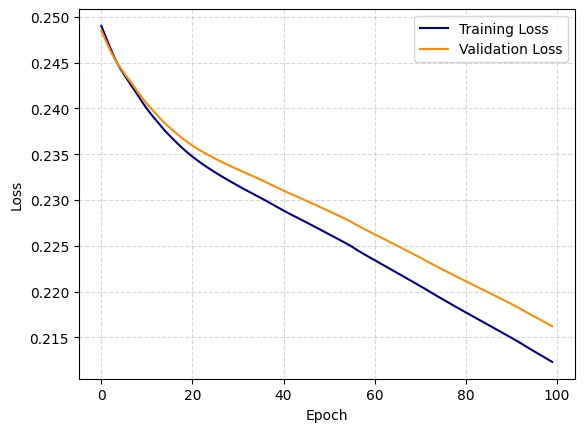

In [11]:
# 15) Plot the evolution of the loss function history for the training set and the validation set. You will find it in "hist.history[’loss’]" and "hist.history[’val_loss’]".
loss_training = hist.history['loss']
loss_validation = hist.history['val_loss']

plt.plot(loss_training, label='Training Loss',color='darkblue')
plt.plot(loss_validation, label='Validation Loss',color='darkorange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### 15) *Analyse the accuracy of the training. Does the training converge?*
#### Yes, it is. Both the training and validation loss drop smoothly from  ~0.30 and stabilize ~0.23 by the 100th epoch. Because the validation loss flattens out right alongside the training loss without curving back up, we can confidently say the model has converged without overfitting.


In [12]:
# 16) Define the "accuracy" of your NN using the validation set. The accuracy is defined as as #correct answers/#total . Use
# the method "predict()" of your "model" in order to compare the answers with the expected ones.
y_pred_prob = model.predict(X_val)

# Since we are doing binary classification, we can set a threshold of 0.5 to convert probabilities to class labels
y_pred = (y_pred_prob > 0.5).astype(int).flatten()


accuracy = accuracy_score(y_val, y_pred)
print(f"Validation Accuracy after initial training: {accuracy:.4f}")


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 491us/step
Validation Accuracy after initial training: 0.6185


In [13]:
# 17) Compile ONCE before the loop
optimizer2 = keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=optimizer2, loss=keras.losses.BinaryCrossentropy())

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=20, restore_best_weights=True
)

target_accuracy = 0.98
all_train_loss = []
all_val_loss = []

while accuracy < target_accuracy:
    hist2 = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size=16,
        callbacks=[early_stop],
        verbose=0
    )
    # Accumulate loss history across all rounds
    all_train_loss.extend(hist2.history['loss'])
    all_val_loss.extend(hist2.history['val_loss'])

    y_pred_prob = model.predict(X_val, verbose=0)
    y_pred = (y_pred_prob > 0.5).astype(int).flatten()
    accuracy = accuracy_score(y_val, y_pred)
    print(f"Validation Accuracy: {accuracy:.4f}")

Validation Accuracy: 0.9930


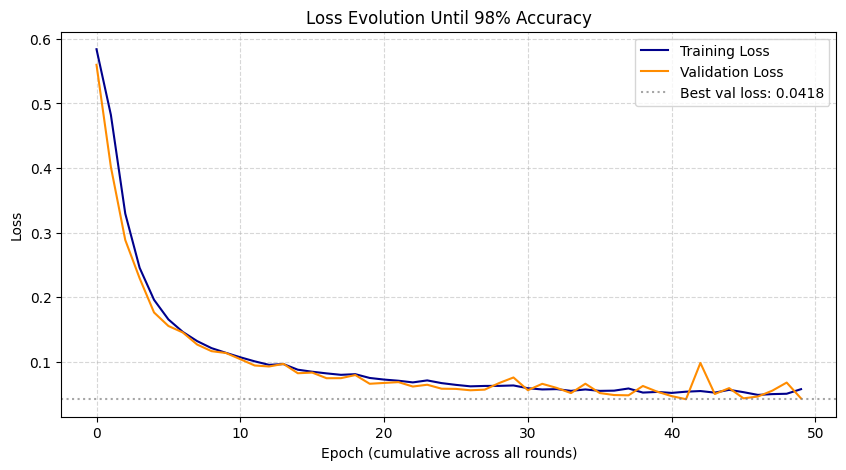

In [14]:
# Plot full loss history across all training rounds
plt.figure(figsize=(10, 5))
plt.plot(all_train_loss, label='Training Loss', color='darkblue')
plt.plot(all_val_loss, label='Validation Loss', color='darkorange')
plt.axhline(y=min(all_val_loss), color='gray', linestyle=':', alpha=0.7, label=f'Best val loss: {min(all_val_loss):.4f}')
plt.xlabel('Epoch (cumulative across all rounds)')
plt.ylabel('Loss')
plt.title('Loss Evolution Until 98% Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### 1.5) What append outside the box?

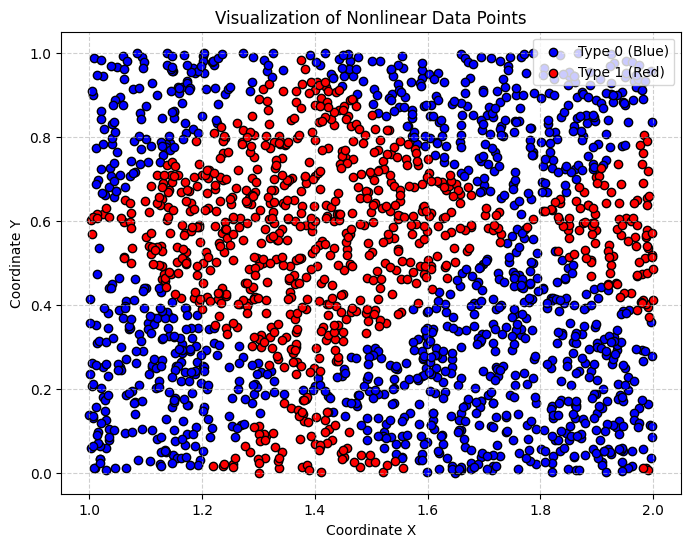

In [15]:
# Now that you have well-trained your NN for classifying the red and blue points inside the box [x,y = (0,1), (0,1)],
# let take a look of how it works when trying to classify points outside this box. We generate 2000 more points,
# in Data_points_nonlin_sup.txt from the same function we use for Data_points_nonlin.txt but inside [x,y = (1,2), (0,1)]


# 18) Apply your NN on these new points and evaluate the accuracy of your NN in classifying them.

data_new = np.loadtxt('Data_points_nonlin_sup.txt')

x_new,y_new,labels_new = data_new[:, 0],data_new[:, 1], data_new[:, 2]

# Filter points based on their type
x_blue,y_blue = x_new[labels_new == 0], y_new[labels_new == 0]

x_red,y_red = x_new[labels_new == 1], y_new[labels_new == 1]


plt.figure(figsize=(8, 6))
plt.scatter(x_blue, y_blue, color='blue', label='Type 0 (Blue)', edgecolors='k')
plt.scatter(x_red, y_red, color='red', label='Type 1 (Red)', edgecolors='k')
plt.title('Visualization of Nonlinear Data Points')
plt.xlabel('Coordinate X')
plt.ylabel('Coordinate Y')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


In [16]:
X_new = data_new[:, :2]   # shape (2000, 2)
y_new_true = data_new[:, 2].astype(int)

# Run the trained model on the new coordinates
y_new_prob = model.predict(X_new, verbose=0)
y_new_pred = (y_new_prob > 0.5).astype(int).flatten()

accuracy_new = accuracy_score(y_new_true, y_new_pred)
print(f"Accuracy on NEW points [x=(1,2), y=(0,1)]: {accuracy_new:.4f}")

Accuracy on NEW points [x=(1,2), y=(0,1)]: 0.5890


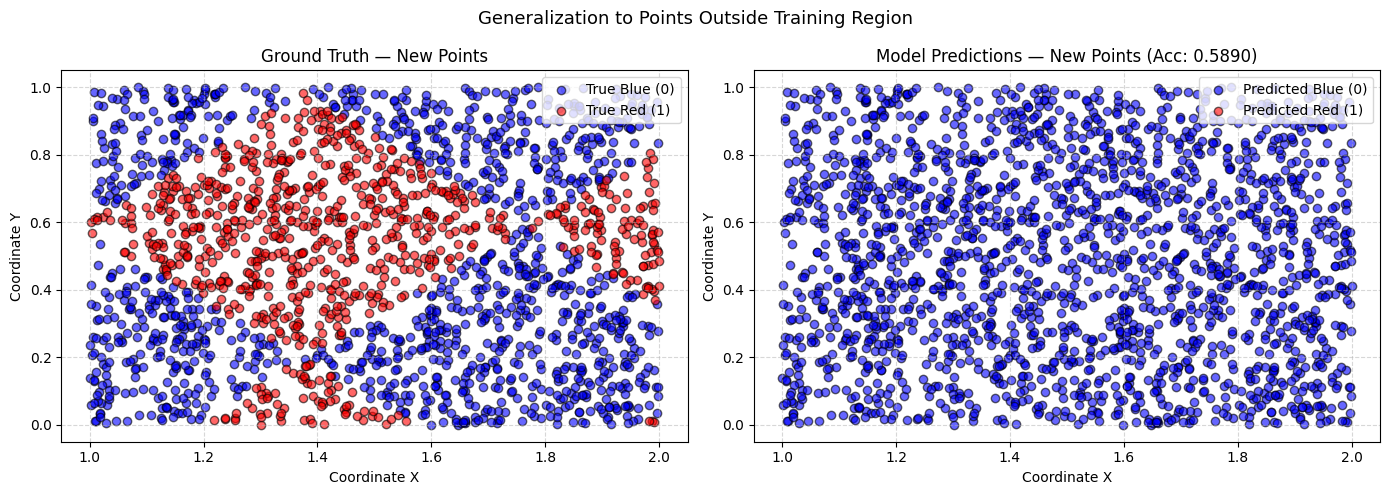

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: ground truth
axes[0].scatter(X_new[y_new_true == 0, 0], X_new[y_new_true == 0, 1],
                color='blue', label='True Blue (0)', edgecolors='k', alpha=0.6)
axes[0].scatter(X_new[y_new_true == 1, 0], X_new[y_new_true == 1, 1],
                color='red',  label='True Red (1)',  edgecolors='k', alpha=0.6)
axes[0].set_title('Ground Truth — New Points')
axes[0].set_xlabel('Coordinate X')
axes[0].set_ylabel('Coordinate Y')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Right: model predictions
axes[1].scatter(X_new[y_new_pred == 0, 0], X_new[y_new_pred == 0, 1],
                color='blue', label='Predicted Blue (0)', edgecolors='k', alpha=0.6)
axes[1].scatter(X_new[y_new_pred == 1, 0], X_new[y_new_pred == 1, 1],
                color='red',  label='Predicted Red (1)',  edgecolors='k', alpha=0.6)
axes[1].set_title(f'Model Predictions — New Points (Acc: {accuracy_new:.4f})')
axes[1].set_xlabel('Coordinate X')
axes[1].set_ylabel('Coordinate Y')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Generalization to Points Outside Training Region', fontsize=13)
plt.tight_layout()
plt.show()

#### 19) What do you conclude on the possibility of using your NN outside the box?
#### Due to our trained model never saw $x \in (1, 2)$. NNs learn a mapping that is only reliable within the distribution of data they were trained on. When inputs fall outside that range, the ReLU activations in the hidden layers either saturate or produce linearly extrapolated values that have no meaningful relationship to the true decision boundary.So, we can conclude *A NN trained on a bounded region cannot be trusted to generalize outside of it. The model is an interpolator, not an extrapolator.*